#  Patient Risk Prediction System

---
**Goal:** Train three classifiers (Logistic Regression, Random Forest,
Gradient Boosting), evaluate with multiple metrics, compare via
ROC curves, Precision-Recall curves, and confusion matrices.


## 4.1 · Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mc
import seaborn as sns
import pickle, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score
)

PRIMARY='#1D4ED8'; ACCENT='#06B6D4'; BG='#EEF4FF'
TEXT='#0F172A'; MUTED='#475569'; DANGER='#EF4444'; SUCCESS='#0D9488'
CMAP = mc.LinearSegmentedColormap.from_list('ocean', [PRIMARY, ACCENT])
COLOURS_3 = [CMAP(i/2) for i in range(3)]

plt.rcParams.update({
    'figure.facecolor':BG, 'axes.facecolor':'white',
    'axes.edgecolor':'#C7D9F0', 'axes.labelcolor':TEXT,
    'xtick.color':MUTED, 'ytick.color':MUTED,
    'grid.color':'#DCE7F7', 'grid.linewidth':0.6,
    'axes.spines.top':False, 'axes.spines.right':False, 'font.size':10,
})
print("Imports OK ✓")


Imports OK ✓


## 4.2 · Load Preprocessed Data from Notebook 3


In [2]:
with open('preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train      = data['X_train']       # imputed, NOT scaled
X_test       = data['X_test']
y_train      = data['y_train']
y_test       = data['y_test']
FEATURE_NAMES= data['feature_names']

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train class balance: {y_train.value_counts().to_dict()}")
print(f"Test  class balance: {y_test.value_counts().to_dict()}")


Train: (614, 8)  |  Test: (154, 8)
Train class balance: {0: 400, 1: 214}
Test  class balance: {0: 100, 1: 54}


## 4.3 · Define Three Model Pipelines

Each pipeline starts with imputation + optional scaling,
then passes data to the classifier.

In [3]:
MODELS = {
    'Logistic Regression': Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  StandardScaler()),
        ('clf',    LogisticRegression(C=0.1, max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('clf',    RandomForestClassifier(
                       n_estimators=200, max_depth=8,
                       min_samples_leaf=4, random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('clf',    GradientBoostingClassifier(
                       n_estimators=200, max_depth=4,
                       learning_rate=0.08, random_state=42))
    ]),
}

print("Models defined:")
for name in MODELS:
    print(f"  ✓ {name}")


Models defined:
  ✓ Logistic Regression
  ✓ Random Forest
  ✓ Gradient Boosting


## 4.4 · Train All Models & Compute Metrics

In [4]:
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
RESULTS = {}

for name, pipe in MODELS.items():
    print(f"Training: {name}...")
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    cv_roc = cross_val_score(pipe, X_train, y_train,
                              cv=cv, scoring='roc_auc', n_jobs=-1)
    report = classification_report(y_test, y_pred, output_dict=True)

    RESULTS[name] = {
        'pipe'        : pipe,
        'y_pred'      : y_pred,
        'y_prob'      : y_prob,
        'accuracy'    : report['accuracy'],
        'precision'   : report['1']['precision'],
        'recall'      : report['1']['recall'],
        'f1'          : report['1']['f1-score'],
        'roc_auc'     : roc_auc_score(y_test, y_prob),
        'ap'          : average_precision_score(y_test, y_prob),
        'cv_roc_mean' : cv_roc.mean(),
        'cv_roc_std'  : cv_roc.std(),
        'cm'          : confusion_matrix(y_test, y_pred),
    }
    print(f"  ROC-AUC: {RESULTS[name]['roc_auc']:.4f}  |"
          f"  F1: {RESULTS[name]['f1']:.4f}  |"
          f"  CV AUC: {cv_roc.mean():.4f} ± {cv_roc.std():.4f}\n")


Training: Logistic Regression...
  ROC-AUC: 0.8104  |  F1: 0.5200  |  CV AUC: 0.8443 ± 0.0160

Training: Random Forest...
  ROC-AUC: 0.8157  |  F1: 0.6061  |  CV AUC: 0.8340 ± 0.0204

Training: Gradient Boosting...
  ROC-AUC: 0.8207  |  F1: 0.6275  |  CV AUC: 0.8079 ± 0.0166



## 4.5 · Results Summary Table


In [5]:
rows = []
for name, res in RESULTS.items():
    rows.append({
        'Model'     : name,
        'Accuracy'  : f"{res['accuracy']:.4f}",
        'Precision' : f"{res['precision']:.4f}",
        'Recall'    : f"{res['recall']:.4f}",
        'F1-Score'  : f"{res['f1']:.4f}",
        'ROC-AUC'   : f"{res['roc_auc']:.4f}",
        'CV AUC'    : f"{res['cv_roc_mean']:.4f}±{res['cv_roc_std']:.4f}",
    })

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

BEST = max(RESULTS, key=lambda k: RESULTS[k]['roc_auc'])
print(f"\n✅ Best Model: {BEST}  (ROC-AUC: {RESULTS[BEST]['roc_auc']:.4f})")


              Model Accuracy Precision Recall F1-Score ROC-AUC        CV AUC
Logistic Regression   0.6883    0.5652 0.4815   0.5200  0.8104 0.8443±0.0160
      Random Forest   0.7468    0.6667 0.5556   0.6061  0.8157 0.8340±0.0204
  Gradient Boosting   0.7532    0.6667 0.5926   0.6275  0.8207 0.8079±0.0166

✅ Best Model: Gradient Boosting  (ROC-AUC: 0.8207)


## 4.6 · Metric Comparison Bar Chart


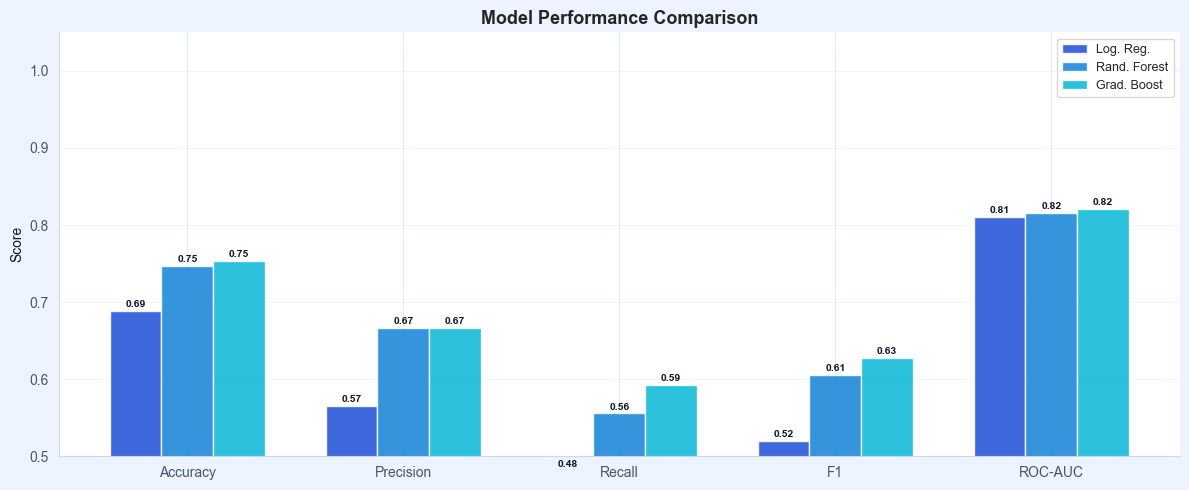

In [16]:
METRICS     = ['accuracy','precision','recall','f1','roc_auc']
MET_LABELS  = ['Accuracy','Precision','Recall','F1','ROC-AUC']
SHORT_NAMES = ['Log. Reg.','Rand. Forest','Grad. Boost']
x           = np.arange(len(METRICS))
width       = 0.24

fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)

for i, (name, res) in enumerate(RESULTS.items()):
    vals   = [res[m] for m in METRICS]
    offset = (i - 1) * width
    bars   = ax.bar(x + offset, vals, width,
                    label=SHORT_NAMES[i], color=COLOURS_3[i],
                    alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.2f}', ha='center', fontsize=7.5, fontweight='bold', color=TEXT)

ax.set_xticks(x); ax.set_xticklabels(MET_LABELS)
ax.set_ylim(0.5, 1.05)
ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=13)
ax.set_ylabel('Score')
ax.legend(fontsize=9)
ax.yaxis.grid(True, alpha=0.5); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('outputs/figures/plot_09_metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 4.7 · ROC Curves

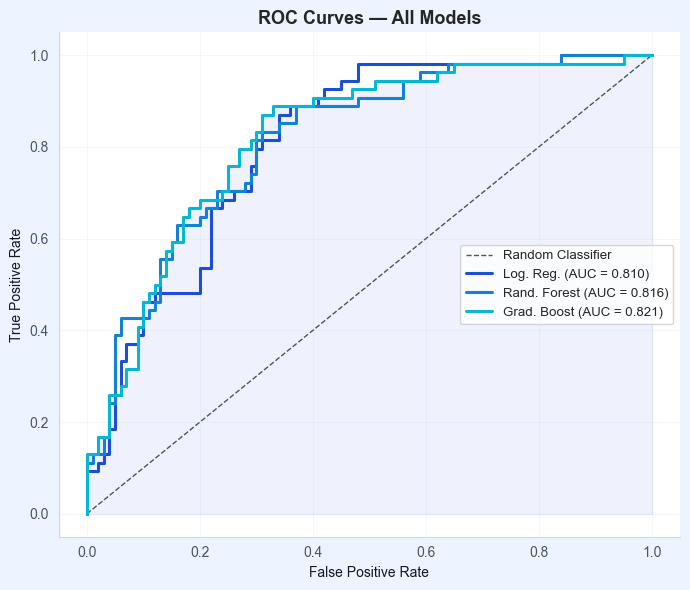

In [17]:
fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG)
ax.plot([0,1],[0,1],'--', color=MUTED, linewidth=1, label='Random Classifier')

for i, (name, res) in enumerate(RESULTS.items()):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=COLOURS_3[i], linewidth=2.2,
            label=f'{SHORT_NAMES[i]} (AUC = {res["roc_auc"]:.3f})')

# Shade under best model curve
fpr_b, tpr_b, _ = roc_curve(y_test, RESULTS[BEST]['y_prob'])
ax.fill_between(fpr_b, tpr_b, alpha=0.07, color=PRIMARY)

ax.set_title('ROC Curves — All Models', fontweight='bold', fontsize=13)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=9.5); ax.grid(alpha=0.35)
plt.tight_layout()
plt.savefig('outputs/figures/plot_10_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 4.8 · Precision-Recall Curves


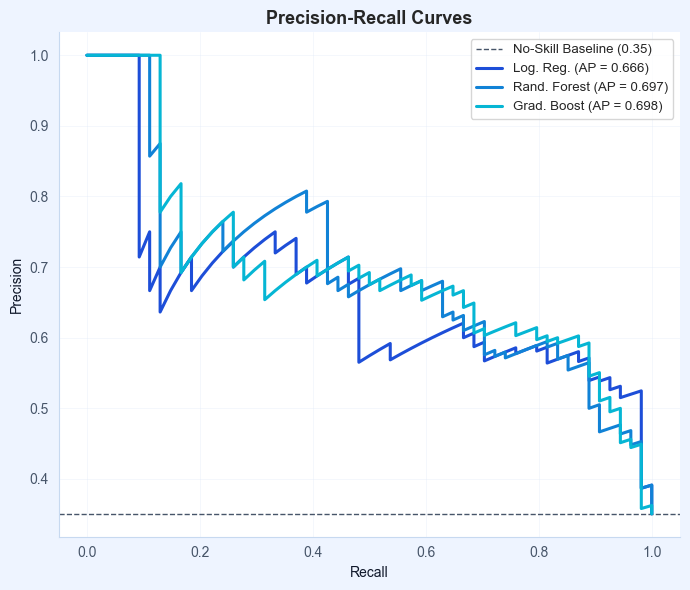

In [18]:
fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG)
baseline = y_test.mean()
ax.axhline(baseline, linestyle='--', color=MUTED, linewidth=1,
           label=f'No-Skill Baseline ({baseline:.2f})')

for i, (name, res) in enumerate(RESULTS.items()):
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ax.plot(rec, prec, color=COLOURS_3[i], linewidth=2.2,
            label=f'{SHORT_NAMES[i]} (AP = {res["ap"]:.3f})')

ax.set_title('Precision-Recall Curves', fontweight='bold', fontsize=13)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.legend(fontsize=9.5); ax.grid(alpha=0.35)
plt.tight_layout()
plt.savefig('outputs/figures/plot_11_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 4.9 · Confusion Matrices


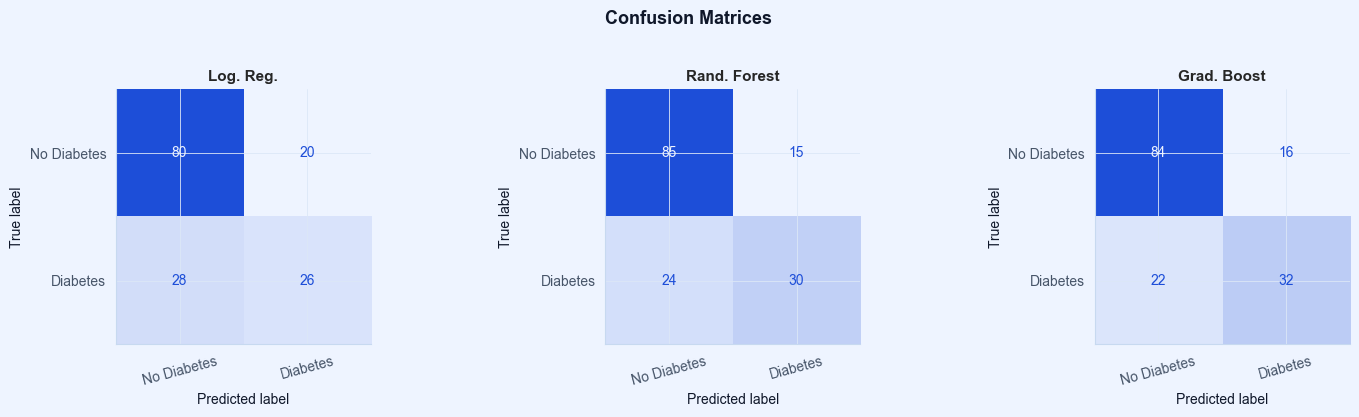

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor=BG)
CMAP_CM = mc.LinearSegmentedColormap.from_list('ocean_cm', ['#EEF4FF', PRIMARY])

for ax, (name, res), short in zip(axes, RESULTS.items(), SHORT_NAMES):
    disp = ConfusionMatrixDisplay(
        confusion_matrix   = res['cm'],
        display_labels     = ['No Diabetes', 'Diabetes']
    )
    disp.plot(ax=ax, colorbar=False, cmap=CMAP_CM)
    ax.set_title(short, fontweight='bold', fontsize=11)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold', y=1.03, color=TEXT)
plt.tight_layout()
plt.savefig('outputs/figures/plot_12_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


## 4.10 · 5-Fold Cross-Validation ROC-AUC


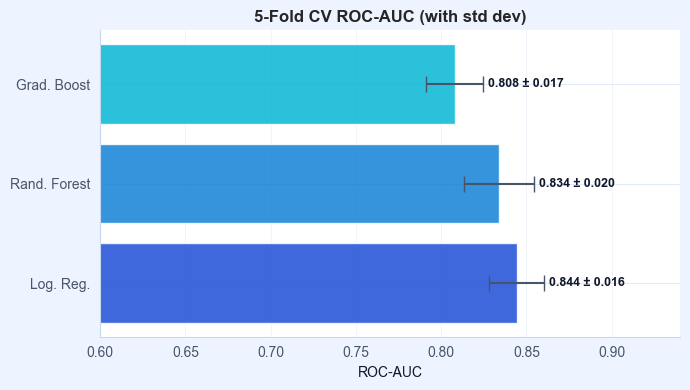

In [20]:
fig, ax = plt.subplots(figsize=(7, 4), facecolor=BG)

cv_means = [RESULTS[n]['cv_roc_mean'] for n in RESULTS]
cv_stds  = [RESULTS[n]['cv_roc_std']  for n in RESULTS]

ax.barh(SHORT_NAMES, cv_means, xerr=cv_stds,
        color=COLOURS_3, alpha=0.85, edgecolor='white',
        capsize=6, error_kw={'ecolor': MUTED, 'linewidth': 1.5})

for i, (m, s) in enumerate(zip(cv_means, cv_stds)):
    ax.text(m + s + 0.003, i, f'{m:.3f} ± {s:.3f}',
            va='center', fontsize=9, fontweight='bold', color=TEXT)

ax.set_title('5-Fold CV ROC-AUC (with std dev)', fontweight='bold', fontsize=12)
ax.set_xlabel('ROC-AUC'); ax.set_xlim(0.60, 0.94)
ax.xaxis.grid(True, alpha=0.5); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('outputs/figures/plot_13_cv_roc_auc.png', dpi=150, bbox_inches='tight')
plt.show()


## 4.11 · Threshold Sensitivity Analysis


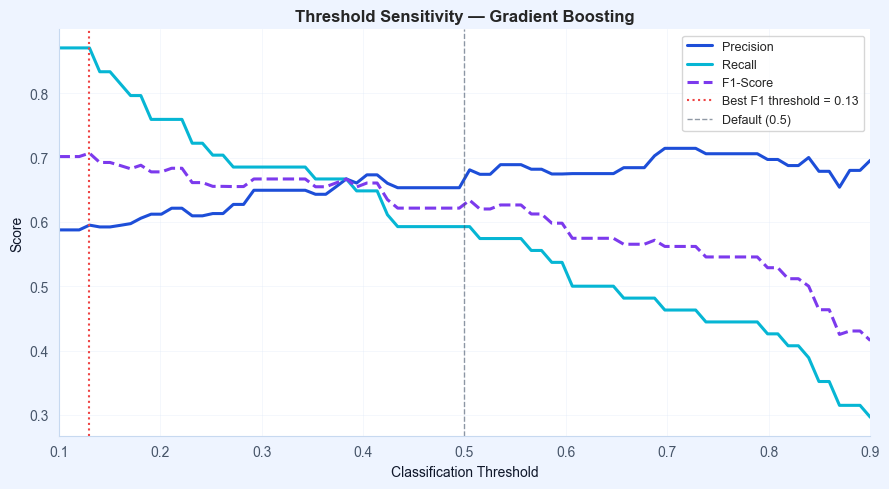

Default threshold (0.50) → Recall: 0.5926, F1: 0.6275
Optimal threshold (0.13) → Recall: 0.8704, F1: 0.7068


In [21]:
best_pipe = RESULTS[BEST]['pipe']
y_prob    = RESULTS[BEST]['y_prob']

thresholds = np.linspace(0.10, 0.90, 80)
precs, recs, f1s = [], [], []

for thr in thresholds:
    preds = (y_prob >= thr).astype(int)
    precs.append(precision_score(y_test, preds, zero_division=0))
    recs.append(recall_score(y_test, preds, zero_division=0))
    f1s.append(f1_score(y_test, preds, zero_division=0))

best_thr = thresholds[np.argmax(f1s)]
best_f1  = max(f1s)

fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
ax.plot(thresholds, precs, color=PRIMARY,   lw=2.2, label='Precision')
ax.plot(thresholds, recs,  color=ACCENT,    lw=2.2, label='Recall')
ax.plot(thresholds, f1s,   color='#7C3AED', lw=2.2, linestyle='--', label='F1-Score')
ax.axvline(best_thr, color=DANGER, lw=1.5, linestyle=':',
           label=f'Best F1 threshold = {best_thr:.2f}')
ax.axvline(0.5, color=MUTED, lw=1, linestyle='--', alpha=0.6, label='Default (0.5)')

ax.set_title(f'Threshold Sensitivity — {BEST}', fontweight='bold', fontsize=12)
ax.set_xlabel('Classification Threshold'); ax.set_ylabel('Score')
ax.legend(fontsize=9); ax.grid(alpha=0.35); ax.set_xlim(0.10, 0.90)
plt.tight_layout()
plt.savefig('outputs/figures/plot_14_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Default threshold (0.50) → Recall: {recall_score(y_test,(y_prob>=0.50).astype(int)):.4f}, "
      f"F1: {f1_score(y_test,(y_prob>=0.50).astype(int)):.4f}")
print(f"Optimal threshold ({best_thr:.2f}) → Recall: {recall_score(y_test,(y_prob>=best_thr).astype(int)):.4f}, "
      f"F1: {best_f1:.4f}")


## 4.12 · Save Best Model


In [13]:
import pickle

best_model_data = {
    'model'        : RESULTS[BEST]['pipe'],
    'model_name'   : BEST,
    'feature_names': FEATURE_NAMES,
    'roc_auc'      : RESULTS[BEST]['roc_auc'],
    'best_threshold': best_thr,
}

with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model_data, f)

print(f"✓ Best model saved to: best_model.pkl")
print(f"  Model     : {BEST}")
print(f"  ROC-AUC   : {RESULTS[BEST]['roc_auc']:.4f}")
print(f"  Best Thr. : {best_thr:.2f}")


✓ Best model saved to: best_model.pkl
  Model     : Gradient Boosting
  ROC-AUC   : 0.8207
  Best Thr. : 0.13
